# EDA

✅ Loading the dataset

✅ Performing data cleaning (handling missing values, duplicates, and outliers)

✅ Performing univariate, bivariate, and multivariate analysis

✅ Data visualization

✅ Feature scaling (normalization and standardization)

📌 Project: Exploratory Data Analysis (EDA) on Iris Dataset

🔹 Objective

Perform EDA on the Iris dataset to extract insights about the petal and sepal lenghs, widths and about the iris sepcies

🔹 Dataset: Iris Dataset

Iris dataset from Kaggle.

# Step 1: Import Necessary Libraries

# Step 2: Load the Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler


In [ ]:


# 2. Move it to the proper location
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json




ref                                                                title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
yashdevladdha/uber-ride-analytics-dashboard                        Uber Data Analytics Dashboard                         17324552  2025-08-08 11:13:42.920000          15947        346  1.0              
mdsultanulislamovi/student-stress-monitoring-datasets              Student Stress Monitoring Datasets                       24336  2025-07-24 16:30:01.617000           8384        128  1.0              
rohitgrewal/airlines-flights-data                                  Airlines Flights Data                                  2440299  2025-07-29 09:16:00.463000          21128        389  1.0

In [ ]:
# 3. Test authentication
!kaggle datasets list

ref                                                                title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
yashdevladdha/uber-ride-analytics-dashboard                        Uber Data Analytics Dashboard                         17324552  2025-08-08 11:13:42.920000          15952        346  1.0              
mdsultanulislamovi/student-stress-monitoring-datasets              Student Stress Monitoring Datasets                       24336  2025-07-24 16:30:01.617000           8387        129  1.0              
rohitgrewal/airlines-flights-data                                  Airlines Flights Data                                  2440299  2025-07-29 09:16:00.463000          21129        389  1.0

In [ ]:
!kaggle datasets download -d himanshu nakrani/iris datset
        # or for competitions:
        # !kaggle competitions download -c <competition-name>

In [ ]:
!kaggle datasets download himanshunakrani/iris-dataset

!unzip iris-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/himanshunakrani/iris-dataset
License(s): CC0-1.0
iris-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  iris-dataset.zip
  inflating: iris.csv                


In [ ]:
# Load dataset
df = pd.read_csv("/content/iris.csv")

# Display first 5 rows
df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# Step 3: Basic Data Exploration



In [ ]:
# Check dataset shape
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

# Check column information
df.info()

# Summary statistics
df.describe()


Dataset has 150 rows and 5 columns.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


# Step 4: Handling Missing Values



In [ ]:
# Check missing values
print(df.isnull().sum())
# print(df.head(100))
# Fill missing sepal_length with median
df['sepal_length'].fillna(df['sepal_length'].median(), inplace=True)
# print(df)
# # Fill missing petal_length with most frequent value
df['petal_length'].fillna(df['petal_length'].mode()[0], inplace=True)



# # Verify missing values are handled
print(df.isnull().sum())


sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


/tmp/ipython-input-475833913.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['sepal_length'].fillna(df['sepal_length'].median(), inplace=True)
/tmp/ipython-input-475833913.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

In [ ]:
# Step 5: Handling Duplicates

# Check for duplicates
print(f"Duplicates in dataset: {df.duplicated().sum()}")

# Remove duplicates if any
df.drop_duplicates(inplace=True)


Duplicates in dataset: 3


In [ ]:
# Step 6: Detecting and Removing Outliers

# Define function to detect outliers
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[column] >= (Q1 - 1.5 * IQR)) & (df[column] <= (Q3 + 1.5 * IQR))]
    return df

# Removing outliers from sepal_width and sepal_length
df = remove_outliers_iqr(df, 'sepal_width')
df = remove_outliers_iqr(df, 'sepal_length')
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


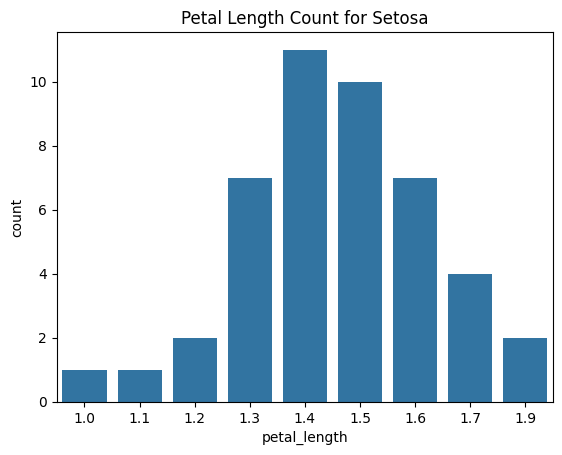

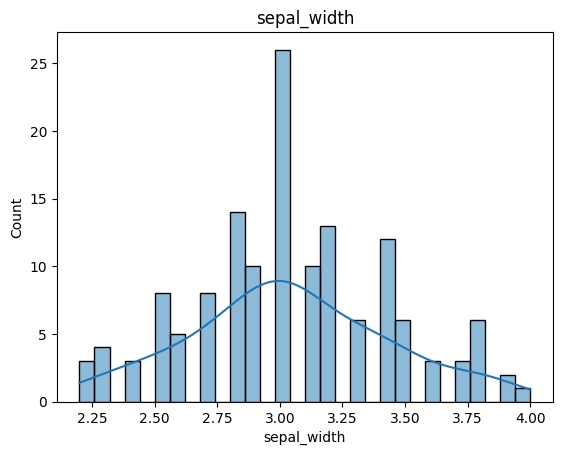

In [ ]:
# Step 7: Univariate Analysis
# Countplot for setosa
setosa_df = df[df['species'] == 'setosa']

# Plot petal_length for setosa
sns.countplot(x='petal_length', data=setosa_df)
plt.title("Petal Length Count for Setosa")
plt.show()

# Histogram for sepal_width distribution
sns.histplot(df['sepal_width'], bins=30, kde=True)
plt.title("sepal_width")
plt.show()


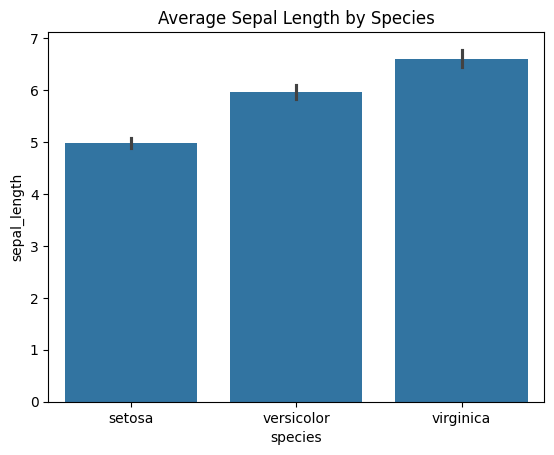

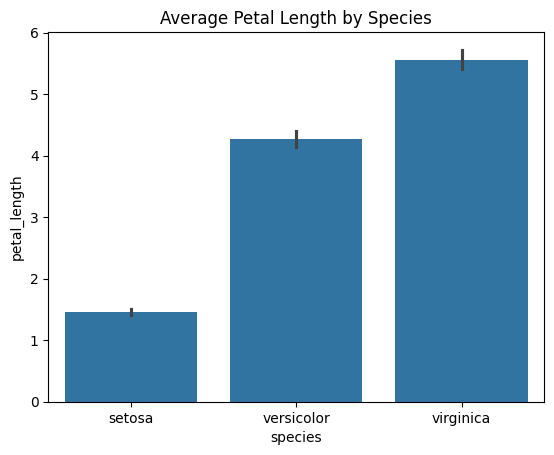

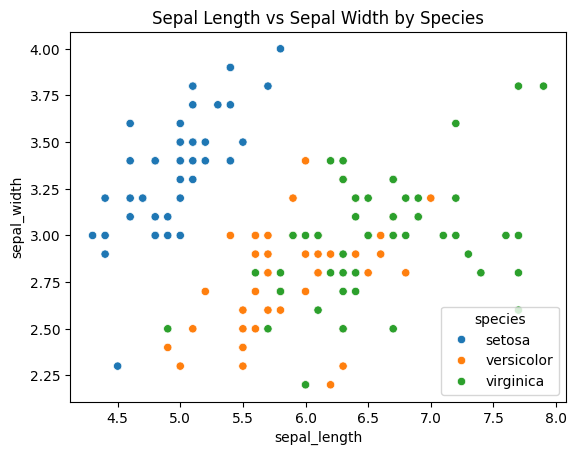

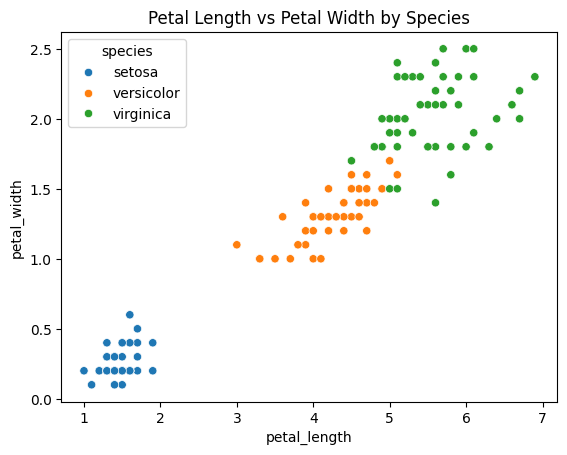

In [ ]:
# Step 8: Bivariate Analysis for Iris

# 1. Mean sepal_length by species
sns.barplot(x='species', y='sepal_length', data=df)
plt.title("Average Sepal Length by Species")
plt.show()

# 2. Mean petal_length by species
sns.barplot(x='species', y='petal_length', data=df)
plt.title("Average Petal Length by Species")
plt.show()

# 3. Scatter plot between sepal_length and sepal_width colored by species
sns.scatterplot(x='sepal_length', y='sepal_width', hue='species', data=df)
plt.title("Sepal Length vs Sepal Width by Species")
plt.show()

# 4. Scatter plot between petal_length and petal_width colored by species
sns.scatterplot(x='petal_length', y='petal_width', hue='species', data=df)
plt.title("Petal Length vs Petal Width by Species")
plt.show()


In [ ]:
# Step 9: Data Normalization & Standardization
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Initialize scaler
scaler = MinMaxScaler()

# Scale numerical columns
numeric_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Display scaled dataframe
df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,0.222222,0.722222,0.067797,0.041667,setosa
1,0.166667,0.444444,0.067797,0.041667,setosa
2,0.111111,0.555556,0.050847,0.041667,setosa
3,0.083333,0.500000,0.084746,0.041667,setosa
4,0.194444,0.777778,0.067797,0.041667,setosa


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Initialize scaler
standardizer = StandardScaler()

# Scale numerical columns
numeric_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
df[numeric_cols] = standardizer.fit_transform(df[numeric_cols])

# Display scaled dataframe
df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,-0.926103,1.163072,-1.393237,-1.370894,setosa
1,-1.166453,-0.096923,-1.393237,-1.370894,setosa
2,-1.406803,0.407075,-1.450554,-1.370894,setosa
3,-1.526978,0.155076,-1.335921,-1.370894,setosa
4,-1.046278,1.415071,-1.393237,-1.370894,setosa


In [ ]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,-0.926103,1.163072,-1.393237,-1.370894,setosa
1,-1.166453,-0.096923,-1.393237,-1.370894,setosa
2,-1.406803,0.407075,-1.450554,-1.370894,setosa
3,-1.526978,0.155076,-1.335921,-1.370894,setosa
4,-1.046278,1.415071,-1.393237,-1.370894,setosa
...,...,...,...,...,...
145,0.996696,-0.096923,0.784798,1.422047,virginica
146,0.515996,-1.356917,0.670165,0.890058,virginica
147,0.756346,-0.096923,0.784798,1.023055,virginica
148,0.395821,0.911073,0.899432,1.422047,virginica
